In this notebook, we demonstrate an End-2-End pipeline for using Presto, a time-series foundation model trained on satellite imagery from different modalities, to generate embeddings and perform similarity search.

Overview
- Input data: Sentinel-2 data downloaded using pystac_client, odc-stac and element84 (or cdse, planetary-computer, openeo, etc...)
- Embeddings: Pass the input through the Presto encoder, resulting in 128-dimensional feature vectors per pixel.
- Similarity search: Use Presto pixel embeddings to search for similar locations using the **cosine similarity** (dot product).
- Unsupervised classification: Presto embeddings as input for Kmeans to perform land cover classification.

In [ ]:
# odc-stac and pystac-client are needed to get data
#%pip install odc-stac pystac-client geopandas --quiet # geopandas is optional but useful for this tutorial
# some viz, ml utilies as also useful 
# uv pip install "presto_eokit[viz,ml] @ git+https://github.com/DHI/presto-eokit.git"

In [22]:
import datetime as dt

import torch
import numpy as np
import xarray as xr
from rasterio.features import shapes
import geopandas as gpd
import shapely.geometry as geometry
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
from pystac_client import Client
from odc.stac import stac_load

import presto_eokit
from presto_eokit import Presto

## Prepare Data

In [2]:
# configs
aoi = [12.453502405425988, 55.797735023427975, 12.510579813262902, 55.8197534642216]
date_start = dt.datetime(2024, 5, 18) 
date_end = dt.datetime(2024, 5, 19)
crs = "epsg:32633"

- In our case we will use the 10m resolution **Sentinel-2** band. But you could also use all of sentinel 2 bands or request any combination of sentinel-2, **Sentinel-s1**: ["VV", "VH"], **ERA5**: ["temperature_2m", "total_precipitation"] and **SRTM**: ["elevation", "slope"]

In [3]:
catalog = Client.open("https://earth-search.aws.element84.com/v1/")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=aoi,
    datetime=f"{date_start:%Y-%m-%d}/{date_end:%Y-%m-%d}",
)
items = search.item_collection() 

In [4]:
ds = stac_load(
    items,
    bands=("blue", "green", "red", "nir"),
    bbox=aoi,
    resolution=10,       
    crs="epsg:32633",      
    chunks={},          
)

In [5]:
rs = ds.compute()
da = rs.sel(time=rs.time[0]).to_array(dim="bands")

In [ ]:
da

In [6]:
s2_bands = ["B2", "B3", "B4", "B8"]
da = da .assign_coords(bands=s2_bands)

## Generate Embeddings

In [9]:
device = "cpu" # torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Presto.load_pretrained(device)
model.to(device)
model.eval()  

Presto(
  (encoder): Encoder(
    (eo_patch_embed): ModuleDict(
      (S1): Linear(in_features=2, out_features=128, bias=True)
      (S2_RGB): Linear(in_features=3, out_features=128, bias=True)
      (S2_Red_Edge): Linear(in_features=3, out_features=128, bias=True)
      (S2_NIR_10m): Linear(in_features=1, out_features=128, bias=True)
      (S2_NIR_20m): Linear(in_features=1, out_features=128, bias=True)
      (S2_SWIR): Linear(in_features=2, out_features=128, bias=True)
      (ERA5): Linear(in_features=2, out_features=128, bias=True)
      (SRTM): Linear(in_features=2, out_features=128, bias=True)
      (NDVI): Linear(in_features=1, out_features=128, bias=True)
    )
    (dw_embed): Embedding(10, 128)
    (latlon_embed): Linear(in_features=3, out_features=128, bias=True)
    (blocks): ModuleList(
      (0-1): 2 x Block(
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=128, out_features=384, bias=True)

In [10]:
band_config = {"s2": s2_bands}

embeds = presto_eokit.generate_embeddings(
    da=da,
    model=model,
    band_configs=band_config,
    month=5, # S2 data is from May 
    timestep_dim=1,
    device=device,  
    batch_size=1024,
    spatial_dims=("y", "x"),
    band_dim="bands",
)

Encoding: 100%|██████████| 93/93 [00:04<00:00, 22.09it/s]


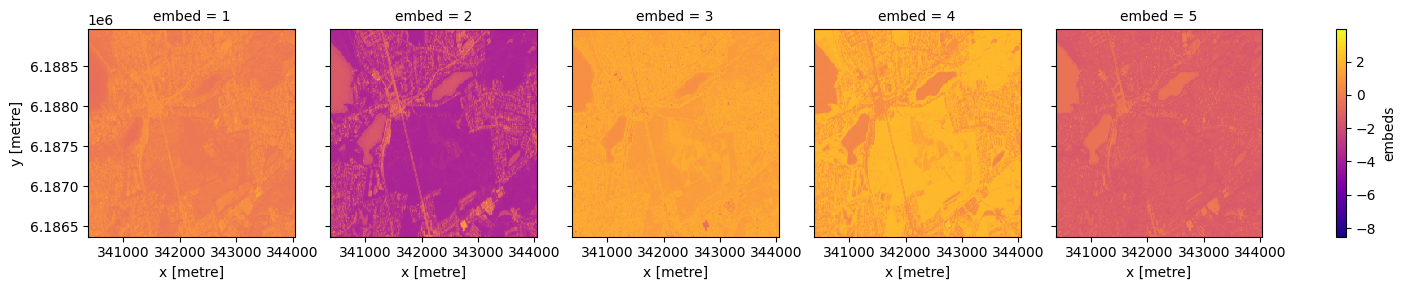

In [11]:
vmin = float(embeds.min())
vmax = float(embeds.max())

subset = embeds.sel(embed=[1, 2, 3, 4, 5])
subset.plot.imshow(
    col="embed",        
    cmap="plasma",
    vmin=vmin,
    vmax=vmax,
    robust=True   
)
plt.show()

In [12]:
# you could select any 3 embeddings channels
rgb_channels = [9, 44, 51]  
rgb_da = embeds.sel(embed=rgb_channels)
rgb_da_norm = (rgb_da - rgb_da.min(dim=("y","x"))) / (rgb_da.max(dim=("y","x")) - rgb_da.min(dim=("y","x"))) # normalize to 0-1

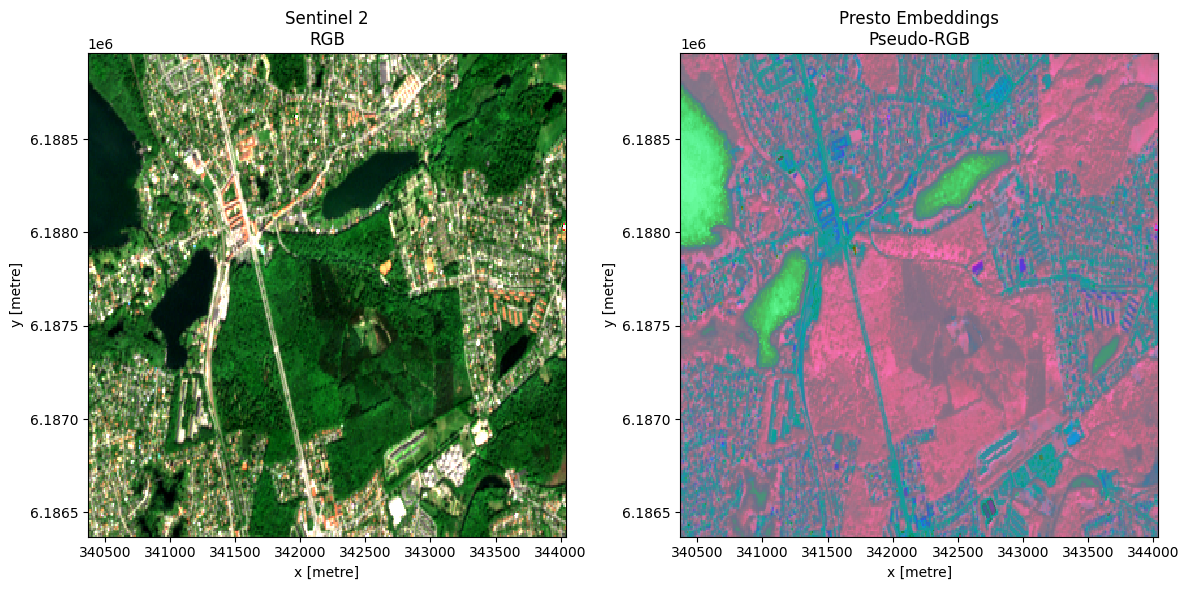

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

s2_rgb = da.sel(dict(bands=["B4", "B3", "B2"]))
s2_rgb.plot.imshow(robust=True, ax=axes[0])
axes[0].set_title("Sentinel 2\nRGB")

rgb_da_norm.plot.imshow(robust=False, ax=axes[1])
axes[1].set_title("Presto Embeddings\nPseudo-RGB")

plt.tight_layout()
plt.show()

## Cosine Similarity on Presto Embeddings

We could use Presto pixel embeddings to search for similar locations using the **cosine similarity** (dot product).
The core idea is simple: Pick a reference location(s) that represents the object(s) of interest and compare all other pixels against it in embedding space.

As an exmaple lets try to find tennis courts. Here we manually select a pixel known to correspond to a **tennis court**.

In [14]:
iy, ix = (114, 228)
ref_pixel = embeds.isel(y=iy, x=ix).values
ref_pixel

array([ 1.0443808 , -2.1042485 ,  1.2684308 ,  1.334567  ,  0.12596051,
        2.0286374 ,  0.50668395,  0.07083879, -0.2262371 ,  0.8822517 ,
       -1.6581662 , -0.56002045,  0.35593694,  0.6248548 , -0.23719406,
       -1.914243  , -0.5573575 ,  0.30725598, -0.03068418,  0.5391165 ,
       -0.7322079 , -1.0089753 , -1.0698221 ,  0.5395135 ,  0.01649143,
        0.63934195,  1.3106486 , -0.28776923, -1.0296487 , -0.5461651 ,
        0.09093622, -1.3393797 ,  0.67934537, -1.6106493 ,  2.6169121 ,
        0.1014597 ,  2.517295  , -0.27734944, -0.49365038, -0.7495655 ,
        1.2713941 ,  2.6603584 ,  1.7263124 , -1.4361881 , -0.0821172 ,
       -0.06828415,  1.3392692 , -1.4666528 , -3.2024224 , -0.39034927,
        1.0385101 ,  1.0021157 ,  0.5723636 ,  0.05135156,  0.2774377 ,
       -0.1284653 ,  0.20972067,  0.8716824 , -1.207065  ,  0.04210716,
        0.5969312 ,  0.1586774 , -0.792327  ,  1.6912004 ,  0.655879  ,
        1.2601309 ,  0.94203484,  0.21224064, -1.2032547 ,  0.59

In [15]:
similarity = presto_eokit.cosine_similarity_map(embeds=embeds, ref_vector=ref_pixel)
similarity

<xarray.DataArray 'cosine_similarity' (y: 259, x: 367)> Size: 380kB
array([[0.82001626, 0.81725365, 0.82304764, ..., 0.8159941 , 0.8054236 ,
        0.7872774 ],
       [0.8171469 , 0.81867456, 0.8262748 , ..., 0.758972  , 0.74272406,
        0.7382247 ],
       [0.82301027, 0.8197644 , 0.82087135, ..., 0.76621073, 0.77408934,
        0.7785253 ],
       ...,
       [0.8072391 , 0.84991884, 0.8510475 , ..., 0.75738657, 0.8337004 ,
        0.8568413 ],
       [0.7787317 , 0.84927577, 0.8473028 , ..., 0.7849499 , 0.8169922 ,
        0.8515579 ],
       [0.8484919 , 0.83774644, 0.8386203 , ..., 0.8265945 , 0.81427616,
        0.84307754]], shape=(259, 367), dtype=float32)
Coordinates:
  * y            (y) float64 2kB 6.189e+06 6.189e+06 ... 6.186e+06 6.186e+06
  * x            (x) float64 3kB 3.404e+05 3.404e+05 ... 3.44e+05 3.44e+05
    spatial_ref  int64 8B 0

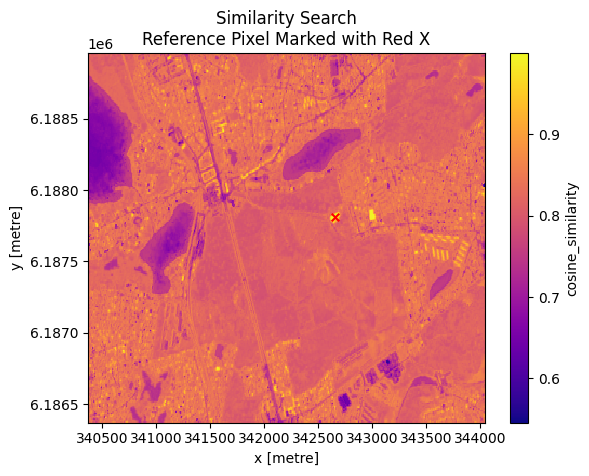

In [16]:
x_coord = similarity.coords["x"].values[ix]
y_coord = similarity.coords["y"].values[iy]

qm = similarity.plot(cmap="plasma")
ax = qm.axes
ax.scatter(x_coord,y_coord,color="red",s=30,marker="x",linewidths=1.5)
ax.set_title("Similarity Search\nReference Pixel Marked with Red X")
plt.show()

- We could set a threshold to find the similar locations.

In [17]:
# Try to experiment with the threshold to find more or fewer matches
threshold = 0.96
matches = similarity > threshold  

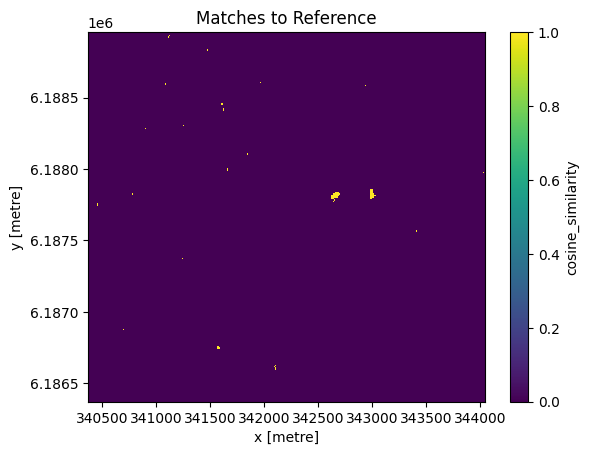

In [18]:
matches.plot()
plt.title("Matches to Reference")
plt.show()

- We could convert the matched pixels to vector data

In [19]:
mask = matches.values.astype(np.uint8)
transform = embeds.rio.transform()

polygons = []
for geom, val in shapes(mask, mask=mask, transform=transform):
    polygons.append(geometry.shape(geom))

gdf = gpd.GeoDataFrame({"geometry": polygons})
gdf.crs = embeds.rio.crs

<Axes: >

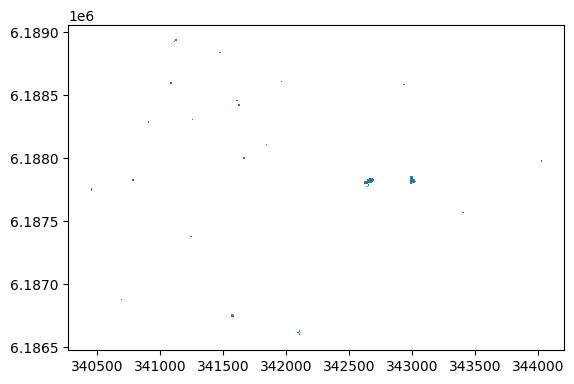

In [20]:
gdf.plot()

## Unsupervised Classification

Lets perform a simple land cover classification using KMeans on the embeddings. Of course this is just a demo, but it shows how we can use the embeddings for downstream tasks. You could also perfom supervised classification or extend this to a regression task if you have training target samples.

In [21]:
# some reshaping 
c, y, x = embeds.shape # [embed, y, x]
embeds_yxe = embeds.transpose("y", "x", "embed") #[y, x, embed]
embeddings_2d = embeds_yxe.values.reshape(y * x, c) # (y*x, embed)
print(embeddings_2d.shape) 

(95053, 128)


In [23]:
n_classes = 5
kmeans = KMeans(n_clusters=n_classes, random_state=42, n_init="auto")
labels = kmeans.fit_predict(embeddings_2d)
labels_img = labels.reshape(y, x)

In [24]:
labels_da = xr.DataArray(
    labels_img,
    dims=("y", "x"),
    coords={"y": embeds.y, "x": embeds.x},
    name="landcover_class"
)
labels_da = labels_da.rio.write_crs(embeds.rio.crs)
labels_da = labels_da.rio.write_transform(embeds.rio.transform())

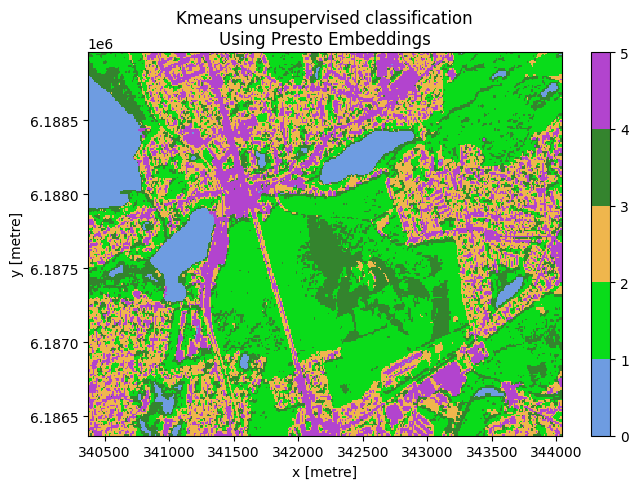

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5)) 

col = ListedColormap(["#6e9ce1", "#09dc1a",  "#efb64d", "#34842e", "#b244ce"])

lc_kmeans_im = labels_da.plot(cmap=col, vmin=0, vmax=5, add_colorbar=False)

ax.set_title('Kmeans unsupervised classification\nUsing Presto Embeddings')
cbar = fig.colorbar(lc_kmeans_im, orientation='vertical')
plt.tight_layout()
plt.show()